In [1]:
# Cellule 1 : Imports et Configuration
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import sys
import os
import numpy as np

# Setup path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from neural_quant.nlp.extractor import CausalEventExtractor
from neural_quant.models.hybrid import HybridJumpDiffusion

print("Imports OK.")

Imports OK.


In [2]:
# Cellule 2 : Définition du Scénario Narratif
# On simule 60 jours de marché via des titres de news.
# C'est un scénario de "Crise du Nickel" typique.

news_timeline = [
    # Jours 0-19 : Calme plat (Bruit de marché)
    "Tech stocks rally on new AI advancements",
    "Fed keeps interest rates unchanged",
    "Copper prices stable amidst balanced supply",
    "Weather report favorable for mining operations",
    "Quarterly earnings show moderate growth",
] * 4  # On répète pour remplir le début

# Jours 20-25 : Rumeurs (Le signal doit commencer à frémir)
news_timeline += [
    "Rumors of labor unrest in major Indonesian nickel mines",
    "Union leaders threaten strike over wage disputes",
    "Analysts warn of potential supply chain disruptions",
    "Nickel futures show slight volatility increase",
    "Negotiations between miners and management stall",
]

# Jours 26-35 : LA CRISE (Grève + Violence -> Signal Max)
news_timeline += [
    "BREAKING: Massive strike hits key Nickel production facility", # Boom
    "Supply disruption expected to last weeks says expert",
    "Violence erupts at mining site, operations halted indefinitely",
    "Global markets react to sudden nickel shortage",
    "Government declares state of emergency in mining province",
    "Major car manufacturers worry about battery metal supply",
    "Export ban considered by local government",
    "Nickel prices surge as inventory hits historic lows",
    "Protests expand to neighboring regions",
    "Military deployed to protect mining infrastructure",
]

# Jours 36-60 : Retour au calme progressif
news_timeline += [
    "Talks resume between union and government",
    "Tentative agreement reached to end hostilities",
    "Miners expected to return to work next week",
    "Supply chain bottlenecks begin to ease",
    "Market volatility decreases as production restarts",
    "Analysts downgrade risk rating for the sector",
    "Nickel production back to 50% capacity",
    "Full operations expected by month end",
    "Investment bank issues neutral rating on mining sector",
    "Weather outlook normal for the season",
] * 2 # Remplissage fin

print(f"Scénario généré : {len(news_timeline)} jours de news.")

Scénario généré : 55 jours de news.


In [3]:
# Cellule 3 : Exécution du Pipeline (NLP -> Math)

def run_simulation():
    # 1. Chargement des modèles
    print("1. Chargement du modèle NLP (Zero-Shot)...")
    nlp_engine = CausalEventExtractor() # Charge BART-Large
    
    print("2. Chargement du modèle SDE Hybride...")
    # input_dim=1 car le NLP sort un score scalaire de 'Risque'
    math_model = HybridJumpDiffusion(input_dim=1, hidden_dim=32)
    
    # 2. NLP : Texte -> Signal Z
    print("3. Analyse des news (Extraction du signal Z_t)...")
    # On traite toutes les news d'un coup
    # Output: [Days, 1]
    z_signal_raw = nlp_engine.process_news_batch(news_timeline)
    
    # Formatage pour le modèle Hybride : [Time, Batch, Dim]
    # On simule 1 seule trajectoire (Batch=1)
    z_series = z_signal_raw.unsqueeze(1) # [60, 1, 1]
    
    # 3. Math : Signal Z -> Prix X, Vol V
    print("4. Simulation Monte Carlo conditionnée...")
    dt = 1.0 / 252.0
    with torch.no_grad():
        prices, vols, jumps = math_model.forward_simulation(z_series, dt=dt)
        
    # Conversion Numpy
    prices = prices[:, 0].numpy()
    vols = vols[:, 0].numpy()
    jumps = jumps[:, 0].numpy()
    signals = z_series[:, 0, 0].numpy()
    
    return prices, vols, jumps, signals

# Lancer le tout
prices, vols, jumps, signals = run_simulation()

1. Chargement du modèle NLP (Zero-Shot)...
Chargement du modèle NLP 'facebook/bart-large-mnli'... (ça peut prendre une minute)


Device set to use cpu


2. Chargement du modèle SDE Hybride...
3. Analyse des news (Extraction du signal Z_t)...
4. Simulation Monte Carlo conditionnée...


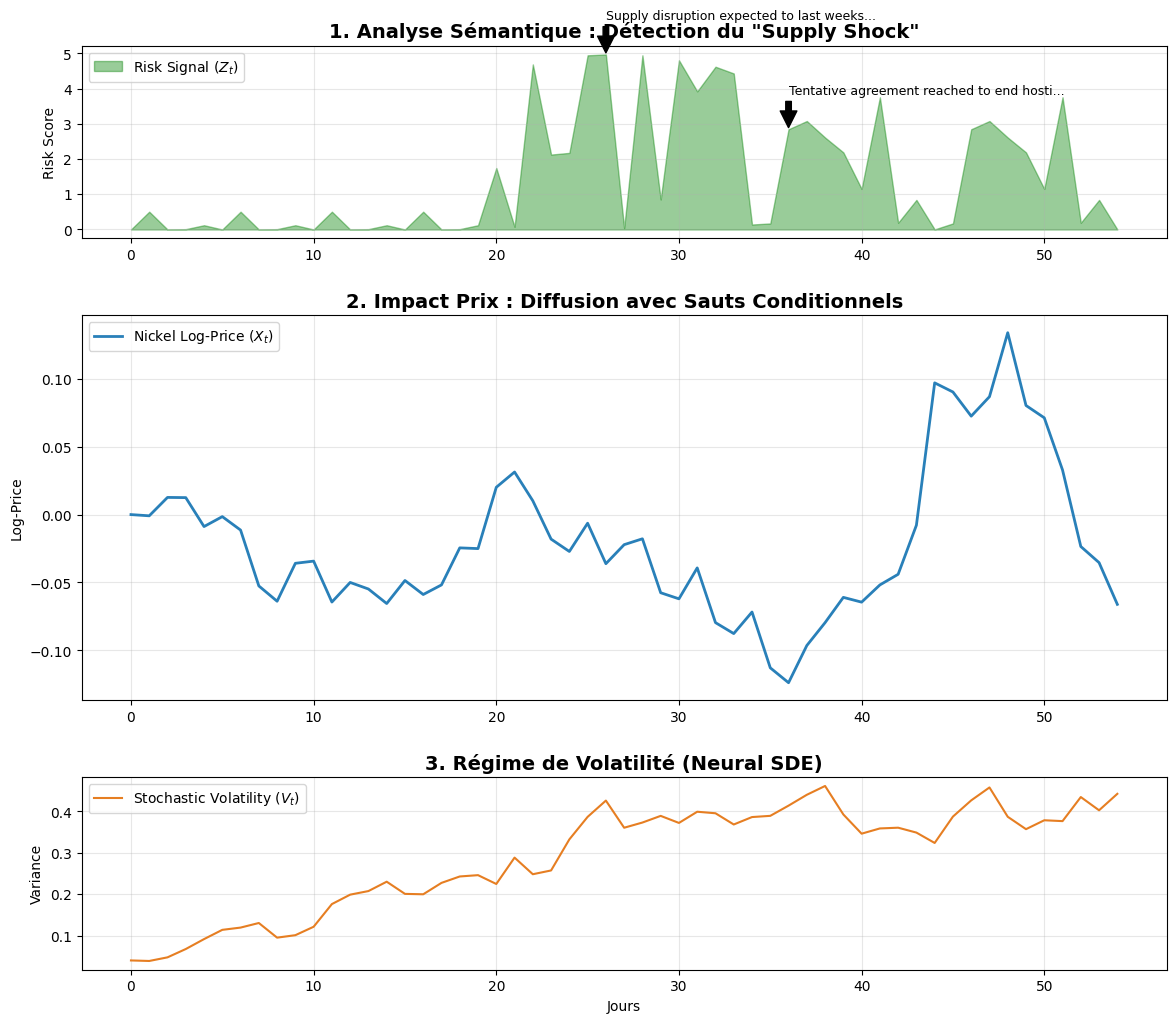

In [4]:
# Cellule 4 : Visualisation "Investor Pitch"

# Création d'un graph complexe
fig = plt.figure(figsize=(14, 12))
grid = plt.GridSpec(3, 1, height_ratios=[1, 2, 1], hspace=0.3)

# --- Panel 1 : L'Input (NLP Signal) ---
ax1 = fig.add_subplot(grid[0])
# On colore la zone de crise
ax1.fill_between(range(len(signals)), signals, color='green', alpha=0.4, label='Risk Signal ($Z_t$)')
ax1.set_title('1. Analyse Sémantique : Détection du "Supply Shock"', fontsize=14, fontweight='bold')
ax1.set_ylabel('Risk Score')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Annotations textuelles sur le graph
indices_cles = [26, 36] # Début et fin crise
for i in indices_cles:
    ax1.annotate(news_timeline[i][:40]+"...", 
                 (i, signals[i]), 
                 xytext=(i, signals[i]+1),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# --- Panel 2 : L'Output (Prix + Sauts) ---
ax2 = fig.add_subplot(grid[1], sharex=ax1)
ax2.plot(prices, color='#2980b9', linewidth=2, label='Nickel Log-Price ($X_t$)')

# Sauts
jump_idx = np.where(jumps > 0)[0]
if len(jump_idx) > 0:
    ax2.vlines(jump_idx, np.min(prices), np.max(prices), 
               colors='#c0392b', linestyles='--', alpha=0.6, label='Jump Event ($dN_t$)')

ax2.set_title('2. Impact Prix : Diffusion avec Sauts Conditionnels', fontsize=14, fontweight='bold')
ax2.set_ylabel('Log-Price')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# --- Panel 3 : La Volatilité ---
ax3 = fig.add_subplot(grid[2], sharex=ax1)
ax3.plot(vols, color='#e67e22', linewidth=1.5, label='Stochastic Volatility ($V_t$)')
ax3.set_title('3. Régime de Volatilité (Neural SDE)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Jours')
ax3.set_ylabel('Variance')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.show()